In [2]:
import networkx as nx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from bp_error.perc_func import declare_vector, perc_log_meesage_pass, update_v_and_messages
import math

In [3]:
N = 30 #no. of nodes
p = 0.1 #ocu
G = nx.erdos_renyi_graph(N, p)
G_di = nx.DiGraph(G)
A = nx.to_numpy_array(G)
pos = nx.spring_layout(G)
labels = {node: str(node) for node in G.nodes()}

{0: Text(-0.07841999124571909, -0.19845993518586233, '0'),
 1: Text(0.2304907090206913, -0.28851076416093824, '1'),
 2: Text(-0.013997229016135801, -0.258093135496109, '2'),
 3: Text(-0.5038406016553116, 0.00833787135664757, '3'),
 4: Text(-0.0256396540723389, 0.37537476854359364, '4'),
 5: Text(-0.47468485140159705, -0.2613350634485434, '5'),
 6: Text(-0.25552236147712487, 0.16410916287072924, '6'),
 7: Text(0.31725046094625303, -0.060191907953604414, '7'),
 8: Text(0.14126683185362424, 0.16836503098260608, '8'),
 9: Text(0.37703669207082363, 0.28732361949179414, '9'),
 10: Text(0.3352950655495322, 0.07802305529015444, '10'),
 11: Text(-0.3828785343096359, -0.5950725350363376, '11'),
 12: Text(0.6255693457991639, 0.29114229080247744, '12'),
 13: Text(0.06824000498450869, 0.09742537842083926, '13'),
 14: Text(-0.3977526527746544, -0.16182754289834927, '14'),
 15: Text(-0.6313161378349329, 0.005236984368412234, '15'),
 16: Text(-0.025503589823065373, -0.004088987377396971, '16'),
 17: T

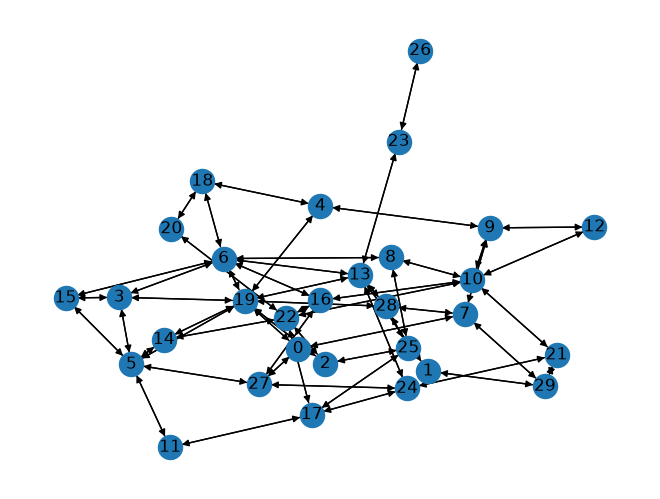

In [163]:
nx.draw(G_di, pos)
nx.draw_networkx_labels(G, pos, labels)

In [4]:
edge_list = list(G_di.edges())
edge_loc = {edge: index for index, edge in enumerate(edge_list)}

num_directed_edges = len(edge_list)

In [ ]:
B = [
    [0 for _ in range(num_directed_edges)]
    for _ in range(num_directed_edges)
]

for row, (i, j) in enumerate(edge_list):
    for col, (k, l) in enumerate(edge_list):
        if l == i and k != j:
            B[row][col] = 1

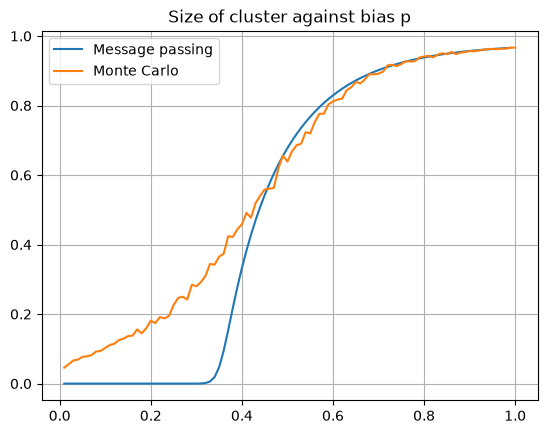

In [81]:
import numpy as np
import EoN
B = jnp.array(B)

#instantiation of the message passing starts here
monte_s_values = []
s_values = []
p_values = []

marginals = []

node_probs = []

for p_choice in np.arange(1, 0, -0.01):
    monte_nodes = {n: 0 for n in G_di.nodes()}
    p_values.append(p_choice)
    V = jnp.array([math.log(1-p_choice + p_choice*0.5) for i in range(G_di.number_of_edges())])
    #for the same p, percolate with EoN
    for i in range(100):
        H = EoN.percolate_network(G, p_choice)
        components = nx.connected_components(H)
        giant_component = max(components, key=len)
        for node in giant_component:
            monte_nodes[node] +=1
    
    #equivalent to s_i
    for node in monte_nodes:
        monte_nodes[node] /= 100

    #instantiate the mu_i
    pre_exp_mu_i = {node: 0.0 for node in G_di.nodes()}

    T = 50
    tol = 1e-9
    V_prev = V
    #iteration of message passing starts here
    for j in range(T):
        if j > 0 and jnp.max(jnp.abs(V - V_prev)) < tol:
            break
        V_prev = V
        V = jnp.log(1 - p_choice + p_choice * jnp.exp(jnp.matmul(B, V)))
    for i, e in enumerate(edge_list):
        pre_exp_mu_i[e[1]] += V[i]

    mu_i = {n: math.exp(pre_exp_mu_i[n]) for n in G_di.nodes()}

    marginals.append(V)

    node_probs.append(list(mu_i.values()))
    s_values.append(1 - (1/N)*jnp.sum(jnp.array(list(mu_i.values()))))
    monte_s_values.append(jnp.sum(jnp.array(list(monte_nodes.values())))/N)

plt.plot(p_values, s_values, label="Message passing")
plt.plot(p_values, monte_s_values, label="Monte Carlo")
plt.legend()
plt.title("Size of cluster against bias p")
plt.grid()

plt.show()

In [11]:
for margin in marginals:
    print(margin[1])

nan
-4.595318
-3.8926046
-3.4778464
-3.181131
-2.9492013
-2.7583292
-2.5958514
-2.454205
-2.3285081
-2.2154245
-2.1125717
-2.0181885
-1.9309349
-1.8497683
-1.7738601
-1.7025412
-1.6352628
-1.5715696
-1.511079
-1.4534663
-1.398454
-1.345802
-1.295302
-1.2467722
-1.2000513
-1.1549978
-1.1114849
-1.0693998
-1.0286412
-0.9891174
-0.950746
-0.9134518
-0.8771663
-0.8418273
-0.80737764
-0.77376443
-0.74093944
-0.70885766
-0.6774774
-0.64675957
-0.6166679
-0.58716786
-0.5582266
-0.52981293
-0.50189656
-0.4744479
-0.44743797
-0.42083752
-0.394617
-0.36874688
-0.3431957
-0.31793112
-0.29291874
-0.26812196
-0.2435023
-0.2190175
-0.19462258
-0.1702697
-0.14591064
-0.12150871
-0.09708677
-0.0728717
-0.049658716
-0.029277002
-0.014208164
-0.005540971
-0.0017660946
-0.00047873988
-0.000114387854
-2.4676627e-05
-5.006803e-06
-7.1525596e-07
0.0
-5.9604645e-08
0.0
-5.9604645e-08
-5.9604645e-08
-1.1920929e-07
0.0
0.0
0.0
0.0
0.0
-5.9604645e-08
0.0
0.0
0.0
0.0
0.0
-5.9604645e-08
0.0
0.0
0.0
0.0
0.0
0.0
0.

In [14]:
for mu_i in node_probs:
    print(mu_i[1])

nan
1.010204337674792e-06
8.166708841584895e-06
2.7862103135643907e-05
6.678431688849381e-05
0.00013194876090741138
0.00023073275729532664
0.00037091431805343815
0.0005607100296147461
0.0008088192937921398
0.0011244657611352027
0.0015174469505241648
0.0019981772178024877
0.002577739029533598
0.0032679363697457353
0.004081336166018554
0.0050313326540713035
0.006132197921751385
0.0073991214793844165
0.008848295127935793
0.010496933666265931
0.012363368990796389
0.014467068145896864
0.016828730866111283
0.01947030204498297
0.022415101731173025
0.02568779379887668
0.029314560126312138
0.03332304146018488
0.03774251872794815
0.042603954116722104
0.047939998540806154
0.053785150442220736
0.06017586428877298
0.06715052493691084
0.07474975584245633
0.08301638196562888
0.09199558428971438
0.1017352370547312
0.11228589571738026
0.12370124312880187
0.1360381227823953
0.1493571485256859
0.16372310583185817
0.17920516144757515
0.19587775356366555
0.21382154658268288
0.23312359090579643
0.2538793560

In [58]:
L = nx.fast_gnp_random_graph(30,0.4)
H = EoN.percolate_network(L, 0.6)

In [70]:
H = EoN.percolate_network(H, 0.6)
H.edges()

EdgeView([(14, 21)])